In [1]:
%matplotlib inline

In [ ]:
## FINAL WORKFLOW TO USE - UNDERSAMPLING 

In [ ]:
##SMOTE+randomUndersampling

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

In [151]:
def run_decision_tree_pipeline(file_path, target_column='bug', smote_ratio=0.8):
    """
    Runs SMOTE + undersampling + manual CCP alpha pruning pipeline
    and returns the trained model, performance metrics, and feature importances.
    """
    # -------------------------
    # Load & preprocess
    # -------------------------
    df = pd.read_csv(file_path)
    df = df.dropna()
    df[target_column] = df[target_column].apply(lambda x: 0 if x==0 else 1)
    
    X = df.drop(columns=[target_column])
    y = df[target_column]
    
    print(f"\nDataset: {file_path}")
    print("Original class distribution:")
    print(y.value_counts())
    
    # -------------------------
    # Resample: SMOTE + Undersampling
    # -------------------------
    smote = SMOTE(sampling_strategy=smote_ratio, random_state=42)
    undersample = RandomUnderSampler(sampling_strategy=1.0, random_state=42)
    resample_pipeline = Pipeline([('smote', smote), ('under', undersample)])
    X_res, y_res = resample_pipeline.fit_resample(X, y)
    
    print("Resampled class distribution:")
    print(pd.Series(y_res).value_counts())
    
    # -------------------------
    # Baseline Stratified CV
    # -------------------------
    dt = DecisionTreeClassifier(random_state=42)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    all_test_preds = np.zeros(len(y_res))
    train_accuracies = []
    test_accuracies = []

    for train_index, test_index in skf.split(X_res, y_res):
        X_train, X_test = X_res.iloc[train_index], X_res.iloc[test_index]
        y_train, y_test = y_res.iloc[train_index], y_res.iloc[test_index]

        dt.fit(X_train, y_train)

        train_acc = accuracy_score(y_train, dt.predict(X_train))
        test_acc = accuracy_score(y_test, dt.predict(X_test))
        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)

        all_test_preds[test_index] = dt.predict(X_test)

    print(f"Baseline - Avg Training Accuracy: {np.mean(train_accuracies):.3f}")
    print(f"Baseline - Avg Test Accuracy: {np.mean(test_accuracies):.3f}")
    
    # -------------------------
    # Manual CCP Alpha selection
    # -------------------------
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_res, y_res)
    path = clf.cost_complexity_pruning_path(X_res, y_res)
    ccp_alphas = path.ccp_alphas

    best_alpha = None
    best_score = 0
    best_max_depth = None

    for alpha in ccp_alphas:
        for depth in [4,5,6,7]:
            dt_alpha = DecisionTreeClassifier(
                random_state=42,
                ccp_alpha=alpha,
                max_depth=depth,
                min_samples_leaf=5
            )
            scores = cross_val_score(dt_alpha, X_res, y_res, cv=5, scoring='f1')
            mean_score = np.mean(scores)
            if mean_score > best_score:
                best_score = mean_score
                best_alpha = alpha
                best_max_depth = depth

    print(f"Best CCP Alpha: {best_alpha:.6f}, Best max_depth: {best_max_depth}, CV F1: {best_score:.3f}")

    # -------------------------
    # Train final pruned tree
    # -------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X_res, y_res, test_size=0.2, stratify=y_res, random_state=42
    )

    pruned_tree = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=best_alpha,
        max_depth=best_max_depth,
        min_samples_leaf=5
    )
    pruned_tree.fit(X_train, y_train)

    # -------------------------
    # Evaluate
    # -------------------------
    y_train_pred = pruned_tree.predict(X_train)
    y_test_pred = pruned_tree.predict(X_test)

    print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"Testing Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
    print("\nClassification Report (Test Data):")
    print(classification_report(y_test, y_test_pred))

    # -------------------------
    # Feature Importance
    # -------------------------
    importances = pruned_tree.feature_importances_
    sorted_idx = np.argsort(importances)[::-1]

    plt.figure(figsize=(12,6))
    plt.bar(X.columns[sorted_idx], importances[sorted_idx])
    plt.xticks(rotation=90)
    plt.title(f"Feature Importances - {file_path}")
    plt.show()

    # -------------------------
    # Tree Visualization
    # -------------------------
    plt.figure(figsize=(20,10))
    plot_tree(
        pruned_tree,
        filled=True,
        rounded=True,
        class_names=[str(cls) for cls in np.unique(y_res)],
        feature_names=X.columns,
        fontsize=10
    )
    plt.title(f"Pruned Decision Tree ({file_path})", fontsize=16)
    plt.show()
    
    return pruned_tree



Dataset: C:\Users\sodhi\Desktop\Design Project\combined\df_1.csv
Original class distribution:
bug
0    1342
1     350
Name: count, dtype: int64
Resampled class distribution:
bug
0    1073
1    1073
Name: count, dtype: int64
Baseline - Avg Training Accuracy: 0.993
Baseline - Avg Test Accuracy: 0.797
Best CCP Alpha: 0.001142, Best max_depth: 7, CV F1: 0.771
Training Accuracy: 0.8240
Testing Accuracy:  0.7721

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.74      0.84      0.79       215
           1       0.82      0.70      0.76       215

    accuracy                           0.77       430
   macro avg       0.78      0.77      0.77       430
weighted avg       0.78      0.77      0.77       430



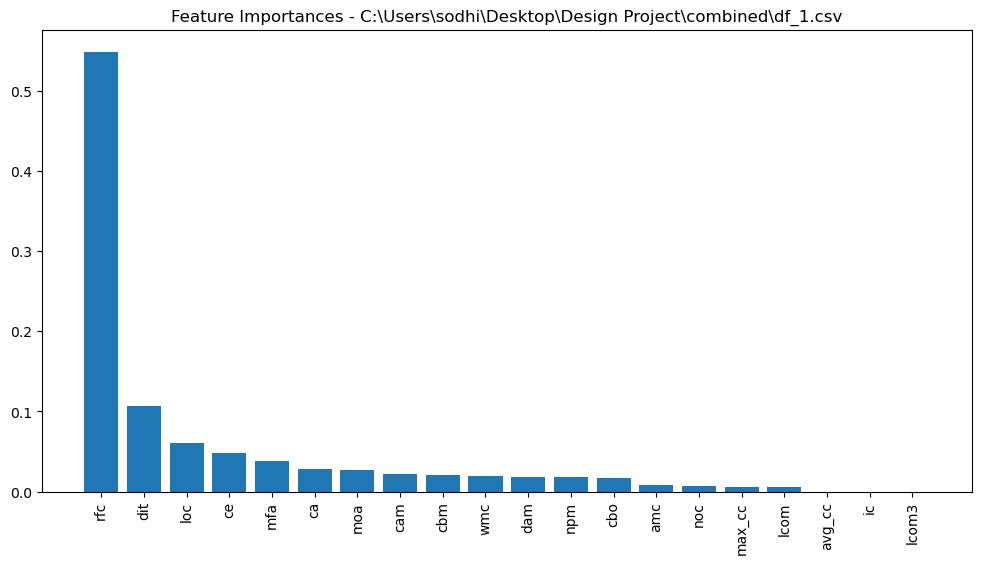

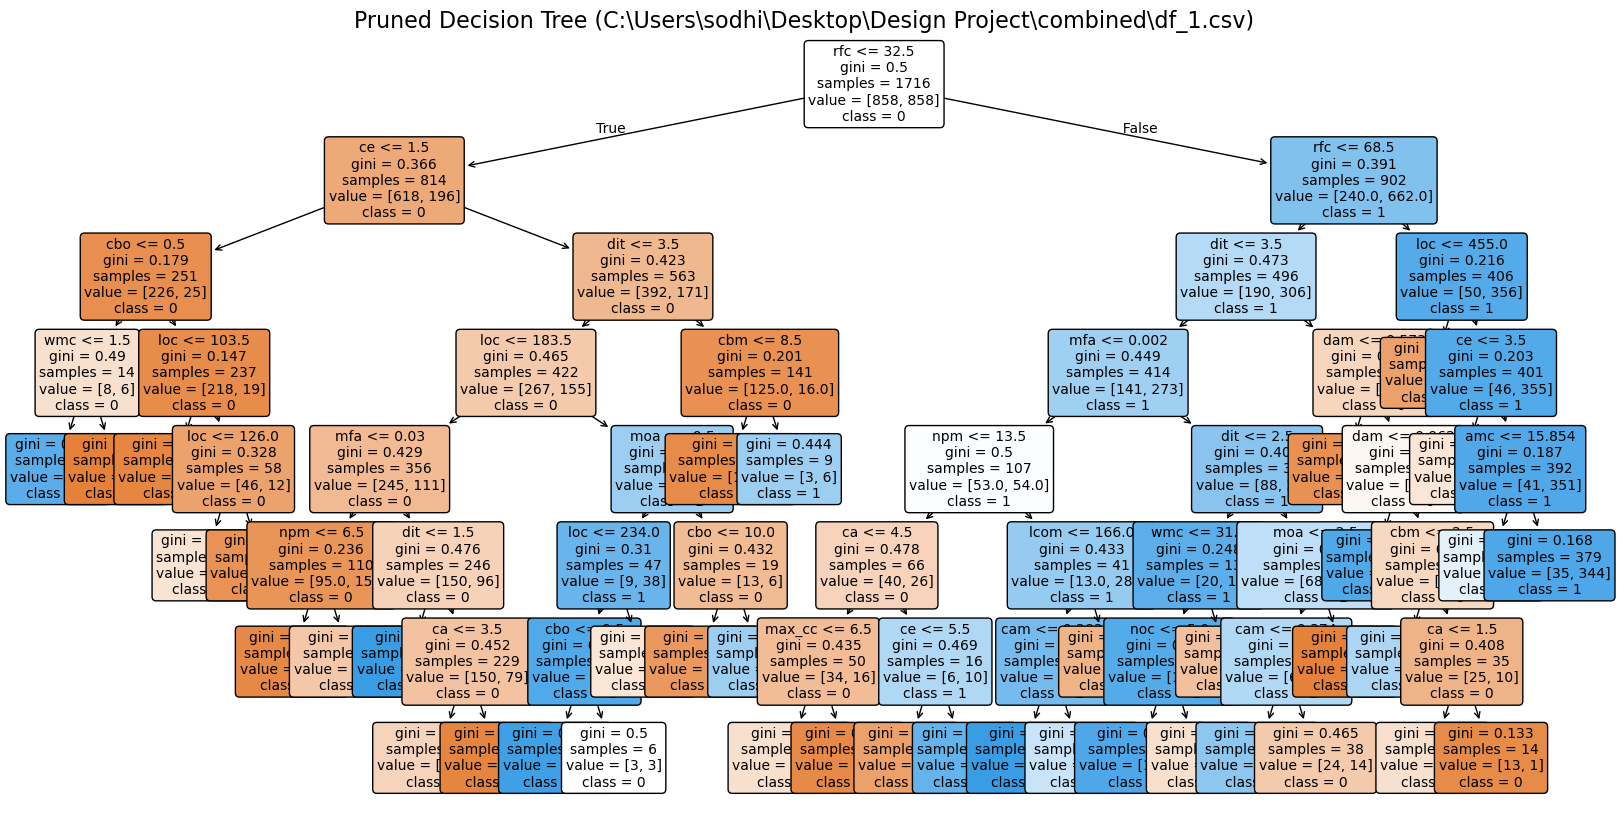


Dataset: C:\Users\sodhi\Desktop\Design Project\combined\df_2.csv
Original class distribution:
bug
0    2222
1     562
Name: count, dtype: int64
Resampled class distribution:
bug
0    1777
1    1777
Name: count, dtype: int64
Baseline - Avg Training Accuracy: 0.978
Baseline - Avg Test Accuracy: 0.790
Best CCP Alpha: 0.000934, Best max_depth: 7, CV F1: 0.702
Training Accuracy: 0.7594
Testing Accuracy:  0.7356

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.78      0.66      0.72       356
           1       0.71      0.81      0.75       355

    accuracy                           0.74       711
   macro avg       0.74      0.74      0.73       711
weighted avg       0.74      0.74      0.73       711



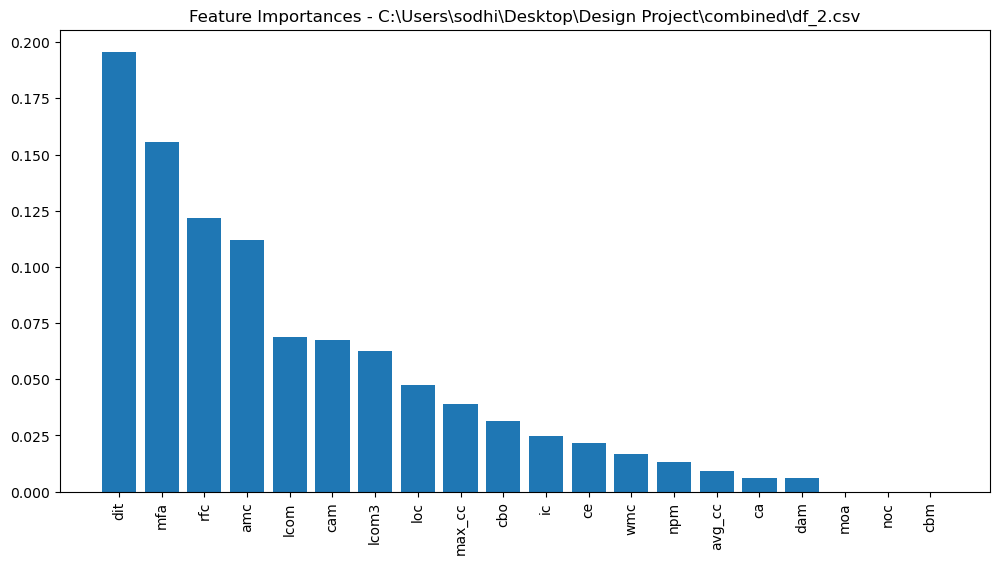

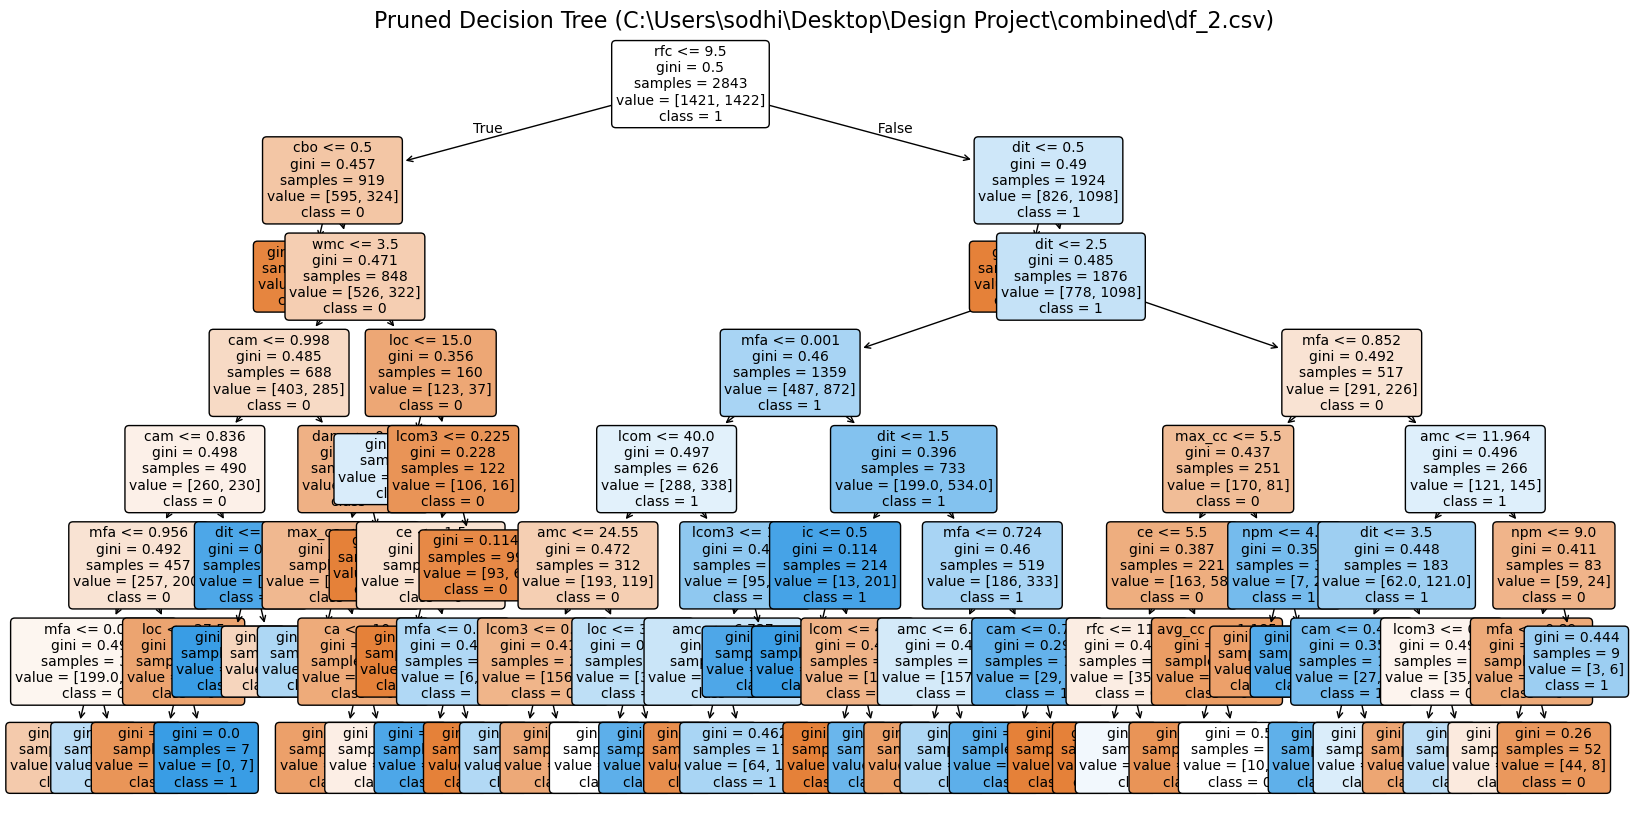


Dataset: C:\Users\sodhi\Desktop\Design Project\combined\df_3.csv
Original class distribution:
bug
0    585
1    119
Name: count, dtype: int64
Resampled class distribution:
bug
0    468
1    468
Name: count, dtype: int64
Baseline - Avg Training Accuracy: 0.999
Baseline - Avg Test Accuracy: 0.792
Best CCP Alpha: 0.000000, Best max_depth: 7, CV F1: 0.775
Training Accuracy: 0.8583
Testing Accuracy:  0.8032

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.84      0.76      0.79        94
           1       0.78      0.85      0.81        94

    accuracy                           0.80       188
   macro avg       0.81      0.80      0.80       188
weighted avg       0.81      0.80      0.80       188



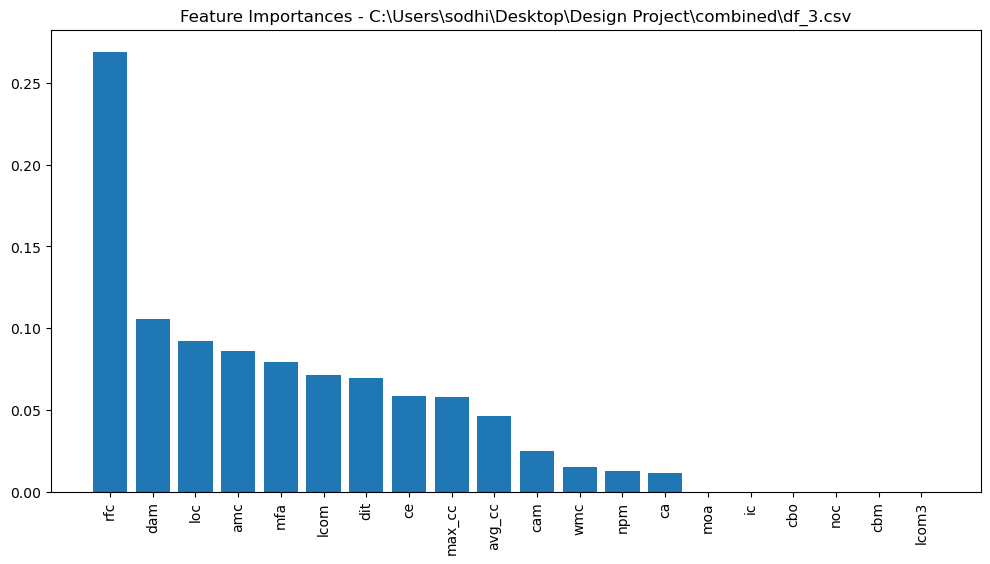

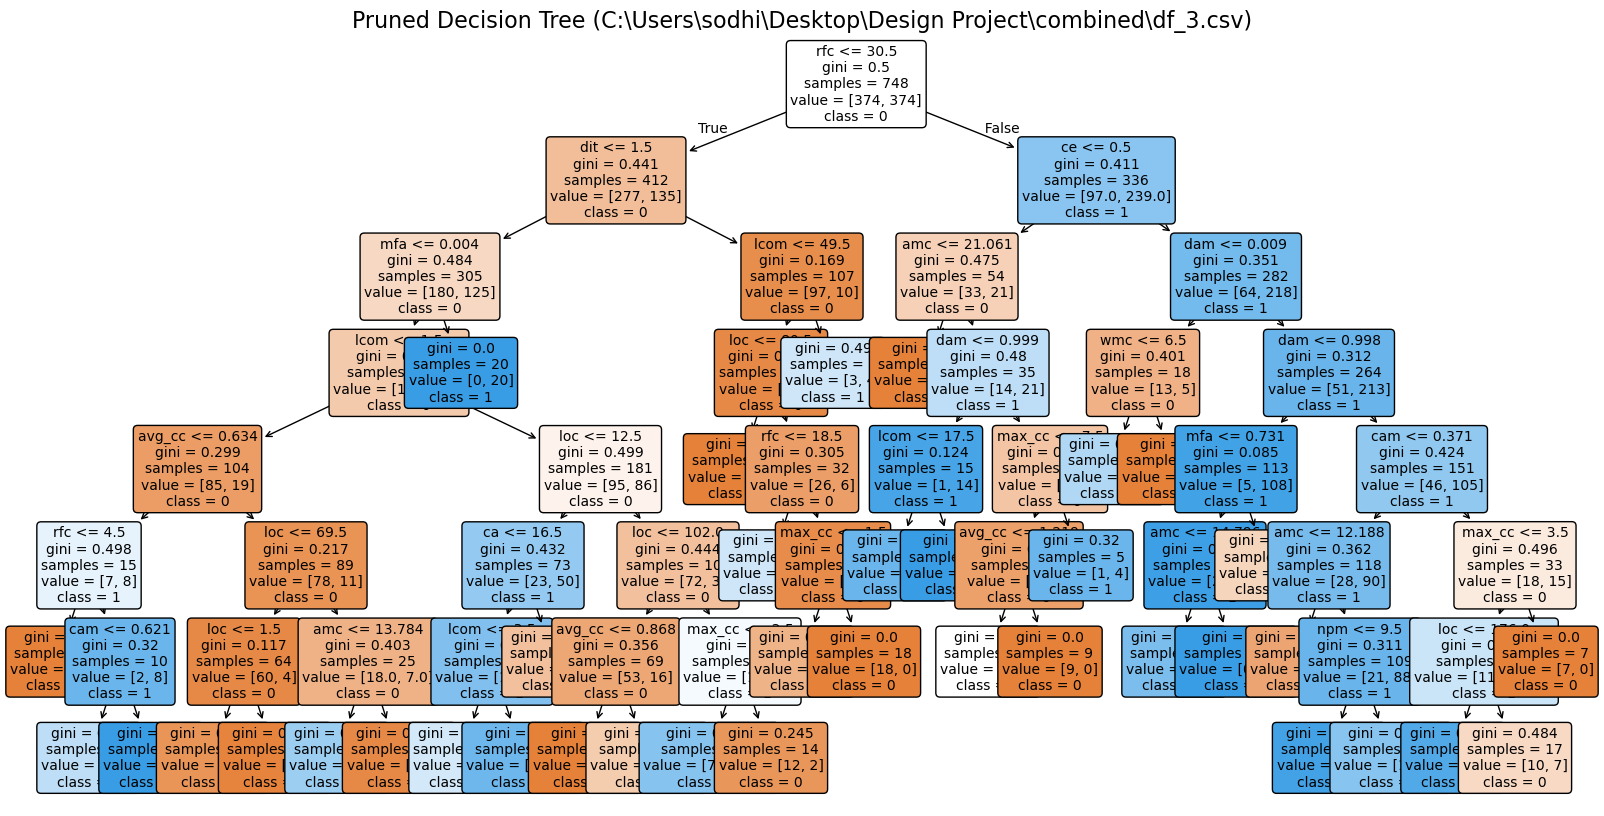


Dataset: C:\Users\sodhi\Desktop\Design Project\combined\df_4.csv
Original class distribution:
bug
0    1446
1     303
Name: count, dtype: int64
Resampled class distribution:
bug
0    1156
1    1156
Name: count, dtype: int64
Baseline - Avg Training Accuracy: 0.996
Baseline - Avg Test Accuracy: 0.827
Best CCP Alpha: 0.000000, Best max_depth: 7, CV F1: 0.783
Training Accuracy: 0.8524
Testing Accuracy:  0.7624

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.85      0.63      0.73       232
           1       0.71      0.89      0.79       231

    accuracy                           0.76       463
   macro avg       0.78      0.76      0.76       463
weighted avg       0.78      0.76      0.76       463



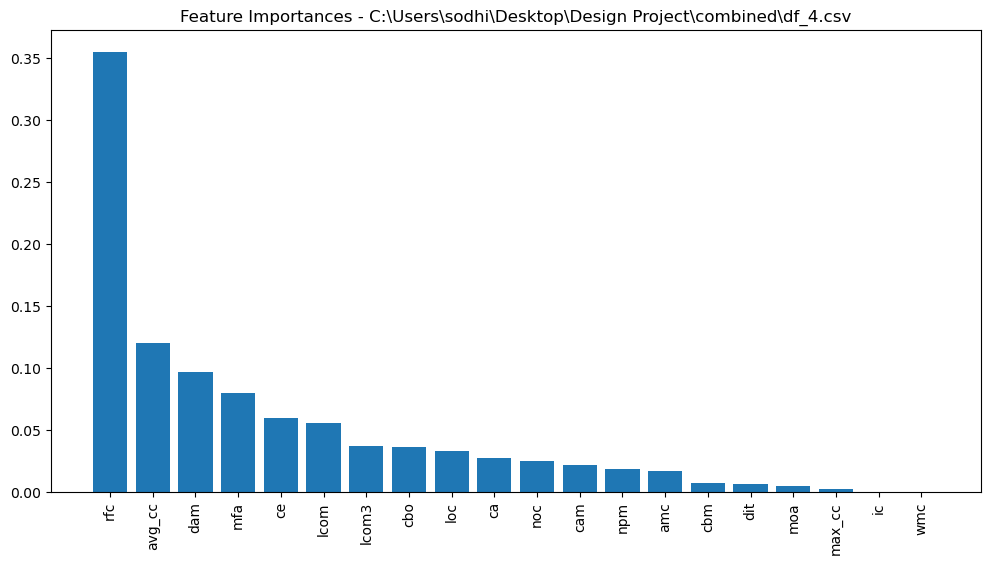

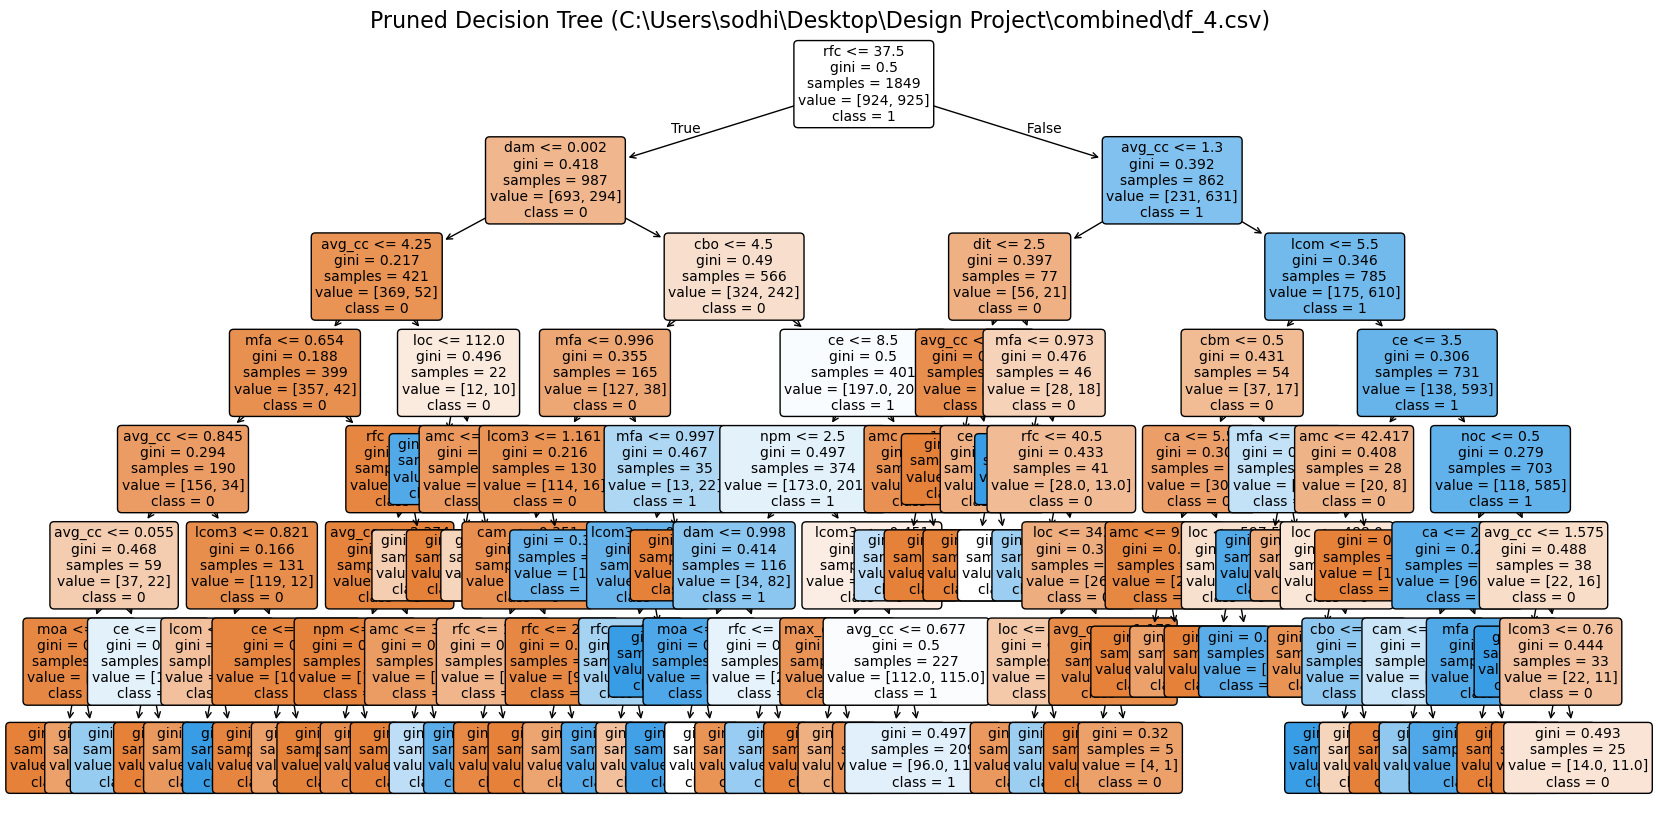


Dataset: C:\Users\sodhi\Desktop\Design Project\combined\df_5.csv
Original class distribution:
bug
1    260
0    189
Name: count, dtype: int64
Resampled class distribution:
bug
0    208
1    208
Name: count, dtype: int64
Baseline - Avg Training Accuracy: 0.900
Baseline - Avg Test Accuracy: 0.620
Best CCP Alpha: 0.002003, Best max_depth: 7, CV F1: 0.598
Training Accuracy: 0.8102
Testing Accuracy:  0.6429

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.61      0.81      0.69        42
           1       0.71      0.48      0.57        42

    accuracy                           0.64        84
   macro avg       0.66      0.64      0.63        84
weighted avg       0.66      0.64      0.63        84



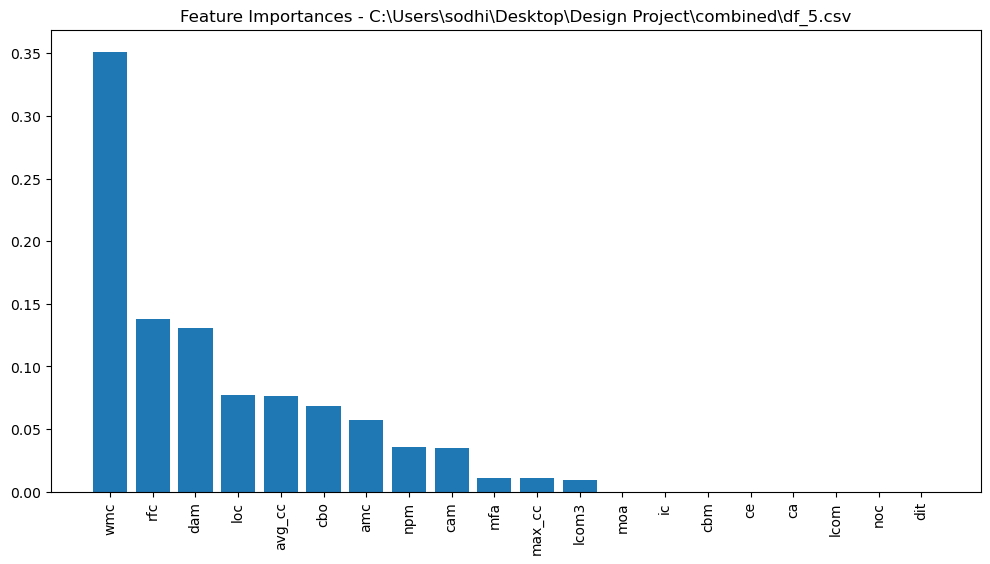

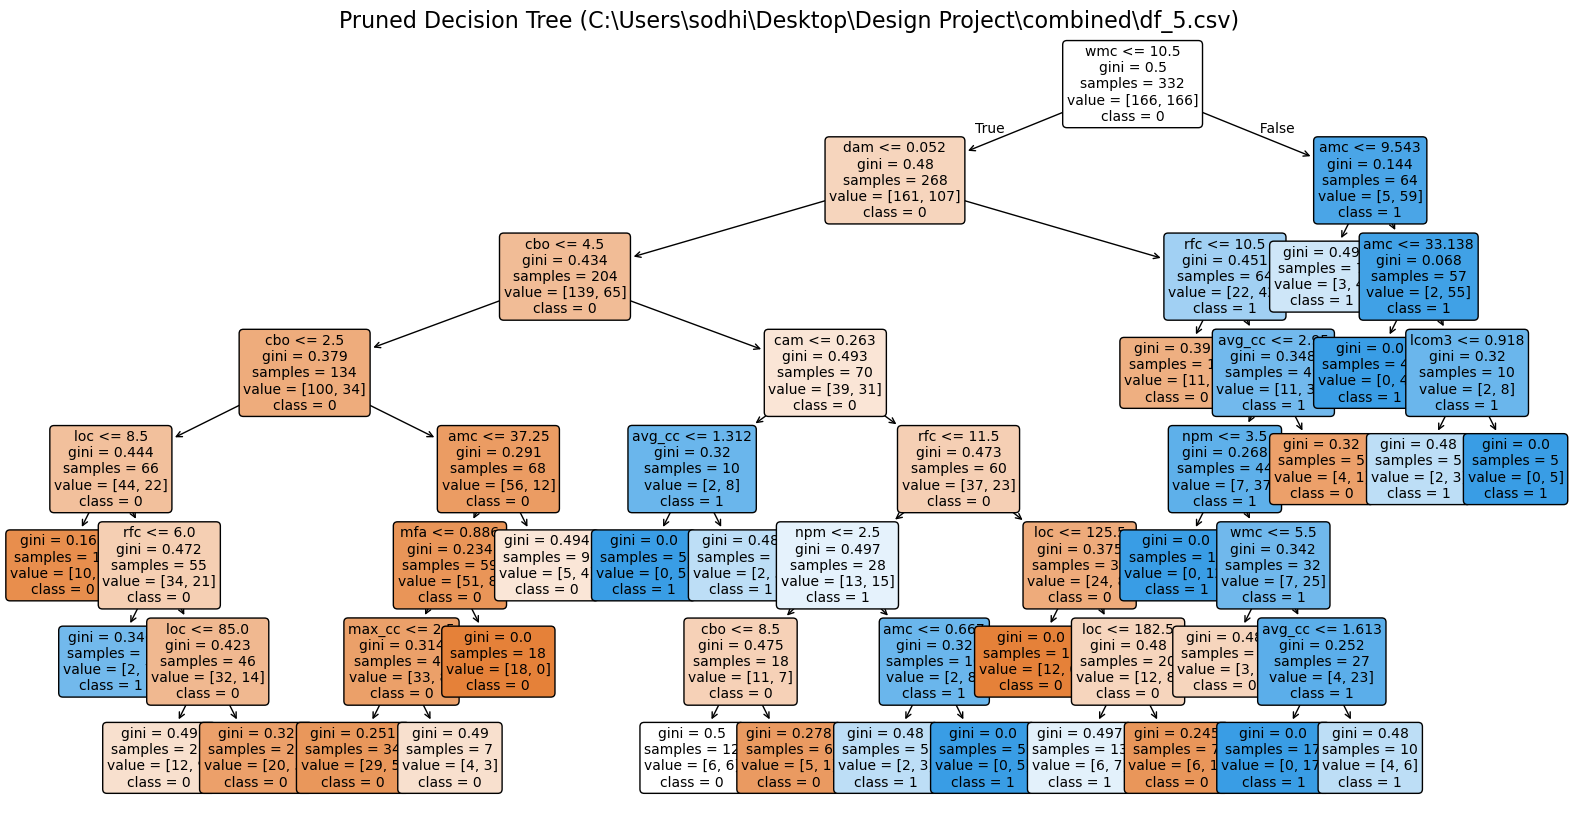

In [167]:
file_paths = [
    r"C:\Users\sodhi\Desktop\Design Project\combined\df_1.csv",
    r"C:\Users\sodhi\Desktop\Design Project\combined\df_2.csv",
    r"C:\Users\sodhi\Desktop\Design Project\combined\df_3.csv",
    r"C:\Users\sodhi\Desktop\Design Project\combined\df_4.csv",
    r"C:\Users\sodhi\Desktop\Design Project\combined\df_5.csv"
]

for fp in file_paths:
    run_decision_tree_pipeline(fp)
